# Homework 8 — Put–Call Parity and Intraday Arbitrage

This notebook contains complete solutions to:

1. **Arbitrage with Put–Call Parity, Section 1**
2. **Arbitrage with Put–Call Parity, Section 2: YTM and Price**
3. **Arbitrage with Put–Call Parity, Section 3: Option Packages**
4. **Intraday Put–Call Parity, Section 1**

The calculations use simple ACT/360 financing, exactly as specified in the exercise. Dollar option positions use a contract multiplier of 100 shares.

In [3]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (11, 5), "font.size": 11})

CONTRACT_MULTIPLIER = 100

## Load the NVDA option-chain data

The cell first looks in common Colab/local locations. If the workbook is absent, it downloads the copy stored with the homework solutions on GitHub.

In [4]:
NVDA_FILENAME = "option_data_bb_NVDA.xlsx"
NVDA_URL = (
    "https://raw.githubusercontent.com/ian-pc/FINM-B-25000/"
    "main/homework-8/option_data_bb_NVDA.xlsx"
)

nvda_candidates = [
    Path.cwd() / NVDA_FILENAME,
    Path.cwd() / "data" / NVDA_FILENAME,
    Path("/content") / NVDA_FILENAME,
    Path("/content/data") / NVDA_FILENAME,
]
NVDA_FILE = next((p for p in nvda_candidates if p.exists()), None)

if NVDA_FILE is None:
    download_dir = Path("/content/hw8_data") if Path("/content").exists() else Path.cwd() / "hw8_data"
    download_dir.mkdir(parents=True, exist_ok=True)
    NVDA_FILE = download_dir / NVDA_FILENAME
    if not NVDA_FILE.exists():
        print("Downloading NVDA workbook from the homework repository...")
        urlretrieve(NVDA_URL, NVDA_FILE)

print("Using NVDA data:", NVDA_FILE)

spot_raw = pd.read_excel(NVDA_FILE, sheet_name="spot", index_col=0)
S = float(spot_raw.loc["price", "NVDA US Equity"])
EXPIRY = "2026-09-18"

option_raw = pd.read_excel(NVDA_FILE, sheet_name=EXPIRY)
calls = option_raw.loc[option_raw["option type"].eq("Call")].set_index("strike price").sort_index()
puts = option_raw.loc[option_raw["option type"].eq("Put")].set_index("strike price").sort_index()
strikes = calls.index.intersection(puts.index).sort_values()

print(f"NVDA spot price: ${S:,.2f}")
print(f"Expiration: {EXPIRY}; common call/put strikes: {len(strikes)}")

Using NVDA data: c:\Users\illus\Documents\Codex\2026-07-23\t\hw8_data\option_data_bb_NVDA.xlsx
NVDA spot price: $208.64
Expiration: 2026-09-18; common call/put strikes: 31


# Part I — Arbitrage with Put–Call Parity

## Section 1 — Put–call parity

For non-dividend-adjusted European pricing, the relevant equality is

\[
C-P=S-PV(K), \qquad PV(K)=\frac{K}{1+r\,d/360}.
\]

Define the parity error as

\[
\varepsilon=(C-P)-[S-PV(K)].
\]

A positive error says the call-minus-put synthetic stock is rich and suggests a **conversion**. A negative error says it is cheap and suggests a **reversal**. Mid prices identify apparent relative-value signals; bid/ask prices determine whether a trade is executable.

### 1.1 Parity error across strikes

,call price,put price,days,finance rate,PV(K),C - P,S - PV(K),parity error
strike,,,,,,,,
130,82.0500,1.0300,102,0.0396,128.5583,81.0200,80.0817,0.9383
135,76.5200,1.2300,102,0.0396,133.5028,75.2900,75.1372,0.1528
140,71.1500,1.4900,102,0.0396,138.4474,69.6600,70.1926,-0.5326
145,66.5900,1.8900,102,0.0396,143.3919,64.7000,65.2481,-0.5481
150,62.2000,2.2200,102,0.0396,148.3365,59.9800,60.3035,-0.3235
155,57.9200,2.7100,102,0.0396,153.2808,55.2100,55.3592,-0.1492
160,54.1500,3.4400,102,0.0396,158.2254,50.7100,50.4146,0.2954
165,49.2100,4.1500,102,0.0396,163.1699,45.0600,45.4701,-0.4101
170,44.7700,5.0500,102,0.0396,168.1144,39.7200,40.5256,-0.8056


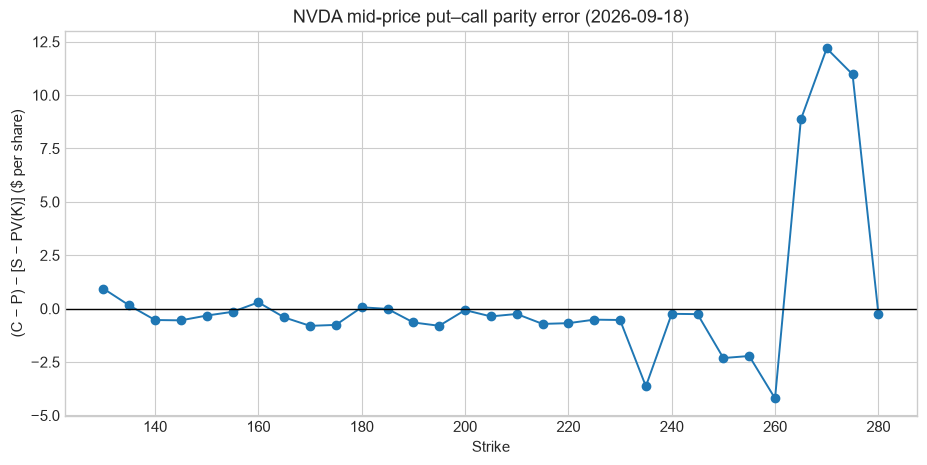

In [5]:
parity = pd.DataFrame(index=strikes)
parity.index.name = "strike"
parity["call price"] = calls.loc[strikes, "price"]
parity["put price"] = puts.loc[strikes, "price"]
parity["days"] = calls.loc[strikes, "days to expiration"]
parity["finance rate"] = calls.loc[strikes, "finance rate"]
parity["PV(K)"] = parity.index / (1 + parity["finance rate"] * parity["days"] / 360)
parity["C - P"] = parity["call price"] - parity["put price"]
parity["S - PV(K)"] = S - parity["PV(K)"]
parity["parity error"] = parity["C - P"] - parity["S - PV(K)"]

display(parity.round(4))

fig, ax = plt.subplots()
ax.plot(parity.index, parity["parity error"], marker="o", lw=1.4)
ax.axhline(0, color="black", lw=1)
ax.set(title=f"NVDA mid-price put–call parity error ({EXPIRY})",
       xlabel="Strike", ylabel="(C − P) − [S − PV(K)] ($ per share)")
plt.show()

The mid-price errors are not close to zero at every strike. However, a mid-price discrepancy alone is not a trade: the correct option bid or ask must be used for every leg. The deep-strike observations also contain stale or internally inconsistent fields, so they should not be interpreted as reliable arbitrage without checking the raw quotes.

### 1.2 Position at the ATM strike, K = 210

In [6]:
K_ATM = 210
N_CONTRACTS = 1_000
Q = N_CONTRACTS * CONTRACT_MULTIPLIER

c210 = calls.loc[K_ATM]
p210 = puts.loc[K_ATM]
days210 = float(c210["days to expiration"])
r210 = float(c210["finance rate"])
pv210 = K_ATM / (1 + r210 * days210 / 360)

mid_error_210 = (c210["price"] - p210["price"]) - (S - pv210)
conversion_edge_210 = (c210["bid"] - p210["ask"]) - (S - pv210)
reversal_edge_210 = (S - pv210) - (c210["ask"] - p210["bid"])

atm_check = pd.Series({
    "Call mid": c210["price"], "Call bid": c210["bid"], "Call ask": c210["ask"],
    "Put mid": p210["price"], "Put bid": p210["bid"], "Put ask": p210["ask"],
    "PV(K)": pv210, "Mid-price parity error": mid_error_210,
    "Executable conversion edge": conversion_edge_210,
    "Executable reversal edge": reversal_edge_210,
})
display(atm_check.to_frame("$ per share").round(4))

,$ per share
Call mid,19.6400
Call bid,19.6500
Call ask,19.8500
Put mid,18.9200
Put bid,18.7000
Put ask,18.9500
PV(K),207.6708
Mid-price parity error,-0.2492
Executable conversion edge,-0.2692
Executable reversal edge,-0.1808


Because the **mid-price parity error is negative**, the apparent trade is a **reversal**:

- Long 1,000 calls at strike 210.
- Short 1,000 puts at strike 210.
- Short 100,000 NVDA shares.
- Lend \(100{,}000\times PV(210)\) until expiration.

At expiration, long call minus short put pays \(S_T-K\), the short stock pays \(-S_T\), and the lending position pays \(K\). The combined expiration payoff is zero in every state. The mid-price signal therefore appears as cash received today.

This is a correction to the supplied Section 1 reference notebook: its printed executable edge is negative, so its subsequent description of a profitable conversion is inconsistent with its own calculation.

### 1.3 Expected P&L and leg-by-leg detail

In [7]:
reversal_legs_mid = pd.DataFrame({
    "Position": ["Long calls", "Short puts", "Short shares", "Lend PV(K)"],
    "Quantity": [N_CONTRACTS, -N_CONTRACTS, -Q, Q],
    "Cash flow today ($)": [
        -c210["price"] * Q,
        +p210["price"] * Q,
        +S * Q,
        -pv210 * Q,
    ],
    "Expiration payoff ($)": [
        "100,000 max(S_T − 210, 0)",
        "−100,000 max(210 − S_T, 0)",
        "−100,000 S_T",
        "+100,000 × 210",
    ],
})
display(reversal_legs_mid)

apparent_profit_210 = -mid_error_210 * Q
executable_profit_210 = reversal_edge_210 * Q

print(f"Apparent reversal profit using mid prices: ${apparent_profit_210:,.2f}")
print(f"Reversal P&L using executable ask/bid quotes: ${executable_profit_210:,.2f}")

,Position,Quantity,Cash flow today ($),Expiration payoff ($)
0,Long calls,1000,"-1,964,000.0000","100,000 max(S_T − 210, 0)"
1,Short puts,-1000,"1,892,000.0000","−100,000 max(210 − S_T, 0)"
2,Short shares,-100000,"20,864,000.0000","−100,000 S_T"
3,Lend PV(K),100000,"-20,767,077.9969","+100,000 × 210"


Apparent reversal profit using mid prices: $24,922.00
Reversal P&L using executable ask/bid quotes: $-18,078.00


Using the reported mid prices, the reversal appears to earn about **$24.9 thousand** immediately. But a reversal must buy the call at its ask and sell the put at its bid. At those executable quotes the P&L is negative, so the ATM observation is **not a true arbitrage**.

### 1.4 Is it an arbitrage, and what risks remain?

The structure suggested by the mid prices is a **reversal**, but it is not an executable arbitrage at the displayed bid/ask quotes. Even a positive quoted edge would still face:

- limited depth: the displayed sizes are far below 1,000 contracts;
- price impact and asynchronous/stale quotes;
- stock-borrow availability and short-sale fees;
- early assignment on American options;
- financing, dividend, margin, and operational risk.

Thus the payoff identity is exact, while implementation at the assumed prices is not.

### 1.5 Financing rate implied by zero profit

In [8]:
# Set C - P = S - K/(1 + r*d/360) and solve for r.
# The exercise's proposed conversion sells the call at bid and buys the put at ask.
pv_zero_conversion = S - (c210["bid"] - p210["ask"])
implied_r_conversion = (K_ATM / pv_zero_conversion - 1) * 360 / days210

# The mid-price rate is also useful as a quote-independent PCP diagnostic.
pv_zero_mid = S - (c210["price"] - p210["price"])
implied_r_mid = (K_ATM / pv_zero_mid - 1) * 360 / days210

# The no-profit rate for the opposite executable reversal uses call ask and put bid.
pv_zero_reversal = S - (c210["ask"] - p210["bid"])
implied_r_reversal = (K_ATM / pv_zero_reversal - 1) * 360 / days210

rate_comparison = pd.Series({
    "Quoted financing rate": r210,
    "Conversion-implied rate (call bid, put ask)": implied_r_conversion,
    "Mid-price parity-implied rate": implied_r_mid,
    "Reversal-implied rate (call ask, put bid)": implied_r_reversal,
})
display(rate_comparison.to_frame("ACT/360 rate").style.format("{:.4%}"))
print(f"Quoted rate: {r210:.4%}")
print(f"Rate that makes the exercise's conversion P&L zero: {implied_r_conversion:.4%}")
print(f"Mid-price parity-implied rate: {implied_r_mid:.4%}")

,ACT/360 rate
Quoted financing rate,3.9586%
"Conversion-implied rate (call bid, put ask)",3.4965%
Mid-price parity-implied rate,3.5308%
"Reversal-implied rate (call ask, put bid)",4.2695%


Quoted rate: 3.9586%
Rate that makes the exercise's conversion P&L zero: 3.4965%
Mid-price parity-implied rate: 3.5308%


Using the exercise's conversion pricing—sell the call at its bid and buy the put at its ask—the zero-profit ACT/360 rate is about **3.4965%**. Using mid prices instead gives **3.5308%**. Both are below the quoted rate of about **3.9586%**. The bid/ask spread creates a no-arbitrage band: the opposite reversal breaks even at about **4.2695%**.

### 1.6 Strike K = 270

In [9]:
K_DEEP = 270
c270 = calls.loc[K_DEEP]
p270 = puts.loc[K_DEEP]
days270 = float(c270["days to expiration"])
r270 = float(c270["finance rate"])
pv270 = K_DEEP / (1 + r270 * days270 / 360)

mid_error_270 = (c270["price"] - p270["price"]) - (S - pv270)
mid_conversion_profit_270 = mid_error_270 * Q
executable_conversion_270 = ((c270["bid"] - p270["ask"]) - (S - pv270)) * Q
executable_reversal_270 = ((S - pv270) - (c270["ask"] - p270["bid"])) * Q

quote_check_270 = pd.DataFrame({
    "Call": c270[["last update date", "price", "bid", "ask", "bid size", "ask size", "open int", "volume"]],
    "Put": p270[["last update date", "price", "bid", "ask", "bid size", "ask size", "open int", "volume"]],
})
display(quote_check_270)
print(f"Apparent mid-price conversion profit: ${mid_conversion_profit_270:,.2f}")
print(f"Executable conversion P&L:            ${executable_conversion_270:,.2f}")
print(f"Opposite executable reversal P&L:     ${executable_reversal_270:,.2f}")

,Call,Put
last update date,2026-06-08 00:00:00,2026-06-02 00:00:00
price,4.0700,50.2500
bid,4.1000,62.9500
ask,4.2000,64.2000
bid size,142,42
ask size,3,20
open int,18970,82
volume,474,10


Apparent mid-price conversion profit: $1,218,593.12
Executable conversion P&L:            $-173,406.88
Opposite executable reversal P&L:     $38,406.88


The price fields suggest an apparent **conversion** profit of roughly **$1.219 million** for 1,000 contracts. That number is not trustworthy:

- The 270 put's reported price is $50.25, but its bid/ask is $62.95/$64.20. A current price or midpoint cannot sit below its own bid.
- The put was last updated on June 2, while the call and spot observations are dated June 8.
- The put has only 82 contracts of open interest and volume of 10; displayed bid/ask sizes are also far below the proposed 1,000-contract trade.
- Using the conversion's executable call bid and put ask produces a loss, not the large mid-price gain.

The opposite bid/ask calculation happens to display a small reversal edge of about $38.4 thousand, but the contradictory/stale put fields and insufficient size make that quote unsuitable evidence of a realizable arbitrage.

## Section 2 — YTM and Price

### 2.1 Option value versus moneyness for the September 2026 expiration

For every strike, use moneyness \(S/K\). The dashed curves show expiration intrinsic value at today's spot, while the solid curves show current option prices.

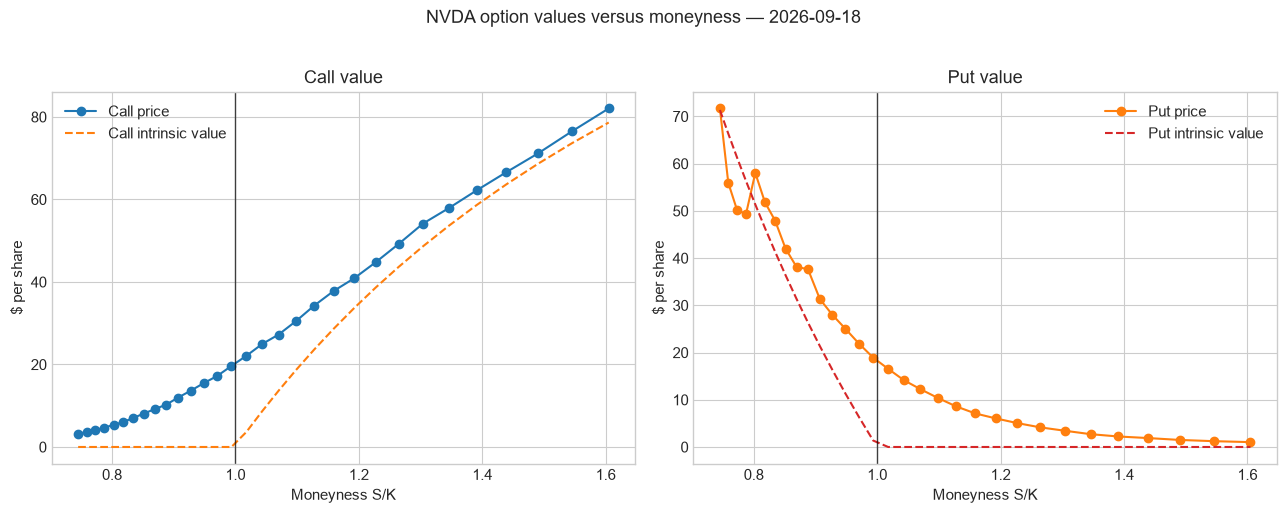

In [10]:
cross_section = pd.DataFrame(index=strikes)
cross_section.index.name = "strike"
cross_section["moneyness S/K"] = S / cross_section.index
cross_section["call value"] = calls.loc[strikes, "price"]
cross_section["put value"] = puts.loc[strikes, "price"]
cross_section["call intrinsic"] = np.maximum(S - cross_section.index.to_numpy(), 0)
cross_section["put intrinsic"] = np.maximum(cross_section.index.to_numpy() - S, 0)
cross_section = cross_section.sort_values("moneyness S/K")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
axes[0].plot(cross_section["moneyness S/K"], cross_section["call value"], marker="o", label="Call price")
axes[0].plot(cross_section["moneyness S/K"], cross_section["call intrinsic"], ls="--", label="Call intrinsic value")
axes[1].plot(cross_section["moneyness S/K"], cross_section["put value"], marker="o", color="tab:orange", label="Put price")
axes[1].plot(cross_section["moneyness S/K"], cross_section["put intrinsic"], ls="--", color="tab:red", label="Put intrinsic value")

for ax, title in zip(axes, ["Call value", "Put value"]):
    ax.axvline(1, color="black", lw=1, alpha=0.7)
    ax.set(title=title, xlabel="Moneyness S/K", ylabel="$ per share")
    ax.legend()
plt.suptitle(f"NVDA option values versus moneyness — {EXPIRY}", y=1.02)
plt.tight_layout()
plt.show()

Calls become more valuable as \(S/K\) rises, while puts become more valuable as \(S/K\) falls. The expiration payoff has a kink at \(S/K=1\) and equals only intrinsic value. Before expiration, both options retain time value, so their prices generally lie above intrinsic payoff, especially near the money. The observed curves are therefore smoother than the terminal-payoff curves.

### 2.2 Option value versus time to expiration at K = 210

Hold strike fixed at 210 and compare the option values across all workbook expirations.

,expiration,days to expiration,call value,put value
0,2026-07-17 00:00:00,39,$10.72,$11.00
1,2026-08-21 00:00:00,74,$15.93,$15.65
2,2026-09-18 00:00:00,102,$19.64,$18.92
3,2026-10-16 00:00:00,130,$22.60,$21.00
4,2026-11-20 00:00:00,165,$26.09,$24.03


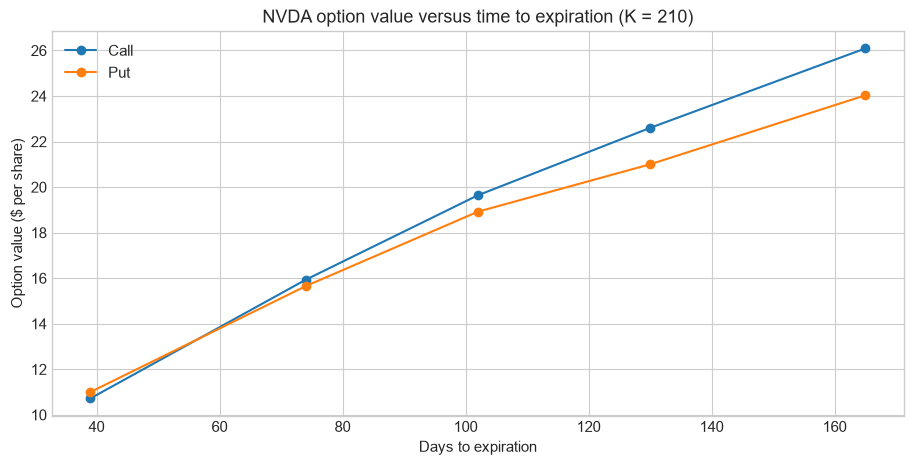

In [11]:
expiry_sheets = [
    s for s in pd.ExcelFile(NVDA_FILE).sheet_names
    if s not in {"spot", "data source"}
]

term_rows = []
for sheet in expiry_sheets:
    chain = pd.read_excel(NVDA_FILE, sheet_name=sheet)
    at_k = chain.loc[chain["strike price"].eq(K_ATM)].set_index("option type")
    term_rows.append({
        "expiration": pd.Timestamp(sheet),
        "days to expiration": int(at_k.iloc[0]["days to expiration"]),
        "call value": float(at_k.loc["Call", "price"]),
        "put value": float(at_k.loc["Put", "price"]),
    })

term_structure = pd.DataFrame(term_rows).sort_values("days to expiration")
display(term_structure.style.format({"call value": "${:.2f}", "put value": "${:.2f}"}))

fig, ax = plt.subplots()
ax.plot(term_structure["days to expiration"], term_structure["call value"], marker="o", label="Call")
ax.plot(term_structure["days to expiration"], term_structure["put value"], marker="o", label="Put")
ax.set(title="NVDA option value versus time to expiration (K = 210)",
       xlabel="Days to expiration", ylabel="Option value ($ per share)")
ax.legend()
plt.show()

At strike 210, both the call and the put become more valuable as expiration moves farther away: the call rises from $10.72 at 39 days to $26.09 at 165 days, and the put rises from $11.00 to $24.03. Extra time creates more opportunity for a large favorable move and therefore more time value. The relationship need not be perfectly smooth in general because implied volatility, rates, dividends, liquidity, and quote timing can differ by expiration; in this sample it is monotone for both options.

## Section 3 — Option packages

Use the September 18, 2026 chain and one option contract per listed option leg. Each contract represents 100 shares.

- **Package A:** long one 210 call and long one 210 put.
- **Package B:** short one 245 call and long one 195 put.
- **Package C:** long 100 shares, short one 245 call, and long one 195 put.

In [12]:
K_A = 210
K_PUT = 195
K_CALL = 245

package_costs = pd.Series({
    "Package A": CONTRACT_MULTIPLIER * (calls.loc[K_A, "price"] + puts.loc[K_A, "price"]),
    "Package B": CONTRACT_MULTIPLIER * (-calls.loc[K_CALL, "price"] + puts.loc[K_PUT, "price"]),
    "Package C": CONTRACT_MULTIPLIER * (S - calls.loc[K_CALL, "price"] + puts.loc[K_PUT, "price"]),
}, name="Initial net cost ($)")

package_summary = pd.DataFrame({
    "Initial net cost ($)": package_costs,
    "Exposure": [
        "Long straddle: long volatility; loses the premium near 210 and benefits from a large move either way.",
        "Bearish risk reversal: protected below 195 and short upside above 245; flat option payoff between strikes.",
        "Collar: long stock with a 195 floor and 245 cap; retains stock exposure between the two strikes.",
    ],
})
display(package_summary.style.format({"Initial net cost ($)": "${:,.2f}"}))

,Initial net cost ($),Exposure
Package A,"$3,856.00",Long straddle: long volatility; loses the premium near 210 and benefits from a large move either way.
Package B,$415.00,Bearish risk reversal: protected below 195 and short upside above 245; flat option payoff between strikes.
Package C,"$21,279.00",Collar: long stock with a 195 floor and 245 cap; retains stock exposure between the two strikes.


The costs are **$3,856 debit** for A, **$415 debit** for B, and **$21,279 debit** for C. Package A is a long straddle, B is a bearish risk reversal, and C is a protective collar.

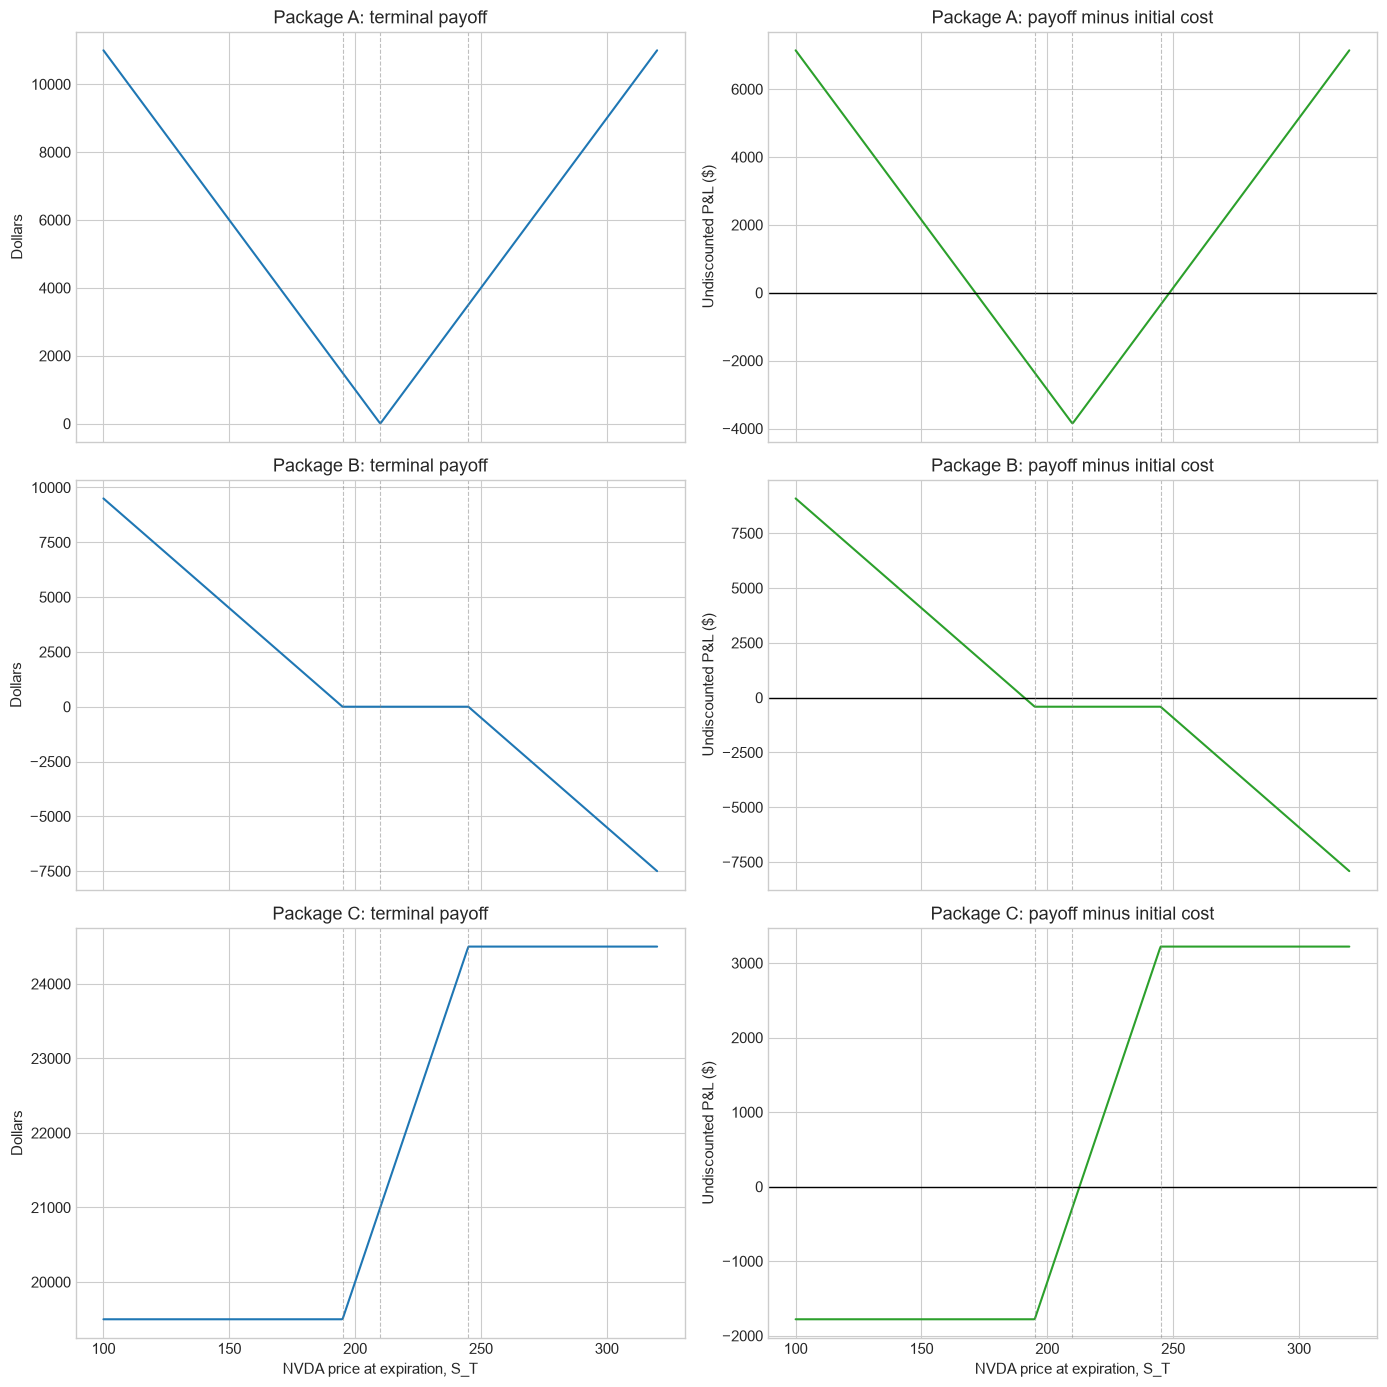

In [13]:
S_T = np.linspace(100, 320, 600)

terminal_payoffs = {
    "Package A": CONTRACT_MULTIPLIER * (np.maximum(S_T - K_A, 0) + np.maximum(K_A - S_T, 0)),
    "Package B": CONTRACT_MULTIPLIER * (-np.maximum(S_T - K_CALL, 0) + np.maximum(K_PUT - S_T, 0)),
    "Package C": CONTRACT_MULTIPLIER * (S_T - np.maximum(S_T - K_CALL, 0) + np.maximum(K_PUT - S_T, 0)),
}

fig, axes = plt.subplots(3, 2, figsize=(14, 14), sharex=True)
for row, name in enumerate(["Package A", "Package B", "Package C"]):
    payoff = terminal_payoffs[name]
    pnl = payoff - package_costs[name]

    axes[row, 0].plot(S_T, payoff, color="tab:blue")
    axes[row, 0].set(title=f"{name}: terminal payoff", ylabel="Dollars")
    axes[row, 1].plot(S_T, pnl, color="tab:green")
    axes[row, 1].axhline(0, color="black", lw=1)
    axes[row, 1].set(title=f"{name}: payoff minus initial cost", ylabel="Undiscounted P&L ($)")

    for ax in axes[row]:
        for strike in [K_PUT, K_A, K_CALL]:
            ax.axvline(strike, color="grey", lw=0.8, ls="--", alpha=0.5)

axes[-1, 0].set_xlabel("NVDA price at expiration, S_T")
axes[-1, 1].set_xlabel("NVDA price at expiration, S_T")
plt.tight_layout()
plt.show()

Package A has its minimum payoff at 210 and gains from sufficiently large moves in either direction. Package B pays positively below 195, zero between 195 and 245, and becomes increasingly negative above 245. Package C floors terminal value at $19,500 below 195, follows the 100-share stock position between 195 and 245, and caps terminal value at $24,500 above 245. The right-hand plots subtract each package's initial cost; they do not compound that cost to expiration.

# Part II — Intraday Put–Call Parity

The original workbook is used if `intraday_options_data_NFLX.xlsx` is available in the notebook directory or a `data` subfolder. Otherwise, the cell constructs the same assignment observations directly so the notebook remains self-contained.

In [14]:
NFLX_FILENAME = "intraday_options_data_NFLX.xlsx"
nflx_candidates = [
    Path.cwd() / NFLX_FILENAME,
    Path.cwd() / "data" / NFLX_FILENAME,
    Path("/content") / NFLX_FILENAME,
    Path("/content/data") / NFLX_FILENAME,
]
NFLX_FILE = next((p for p in nflx_candidates if p.exists()), None)

if NFLX_FILE is not None:
    print("Using NFLX workbook:", NFLX_FILE)
    pcp_info = pd.read_excel(NFLX_FILE, sheet_name="Info")
    pcp_prices = pd.read_excel(NFLX_FILE, sheet_name="Prices", index_col=0, parse_dates=True)
    pcp_options = pd.read_excel(NFLX_FILE, sheet_name="Options", header=[0, 1], index_col=0)
    pcp_vol = pcp_options[[('call', 'volume'), ('put', 'volume')]].dropna()
    pcp_vol.columns = ["call_volume", "put_volume"]

    params = pcp_info.set_index("Parameter")["Value"]
    pcp_date = str(params["Date"])
    pcp_K = float(str(params["Strike Price"]).replace("$", "").replace(",", ""))
    pcp_rate = float(str(params["Finance Rate"]).replace("%", "")) / 100
    pcp_days = int(params["Days to Expiry"])
else:
    print("NFLX workbook not found; using the embedded assignment observations.")
    pcp_date = "2025-07-25"
    pcp_K = 1180.0
    pcp_rate = 0.045866
    pcp_days = 21
    times = ["09:30", "09:55", "10:10", "10:30", "10:45", "11:20", "11:35",
             "12:30", "12:50", "12:55", "13:00", "13:05", "13:15", "14:05"]
    pcp_index = pd.to_datetime([f"{pcp_date} {t}" for t in times])
    pcp_prices = pd.DataFrame({
        "underlying": [1179.58, 1178.05, 1186.58, 1177.59, 1182.92, 1184.56, 1181.90,
                       1185.55, 1186.14, 1185.76, 1183.20, 1182.54, 1182.70, 1180.83],
        "call": [29.47, 29.00, 34.00, 29.07, 31.91, 32.30, 31.20,
                 32.30, 32.50, 33.55, 31.75, 30.70, 30.80, 29.80],
        "put": [27.95, 28.80, 24.47, 27.60, 25.85, 24.95, 26.10,
                24.46, 23.75, 23.42, 24.00, 25.10, 25.00, 25.91],
    }, index=pcp_index)
    pcp_vol = pd.DataFrame({
        "call_volume": [1, 1, 23, 13, 22, 5, 18, 21, 2, 1, 2, 19, 2, 2],
        "put_volume": [1, 3, 3, 2, 3, 1, 2, 1, 1, 1, 1, 1, 2, 6],
    }, index=pcp_index)

display(pcp_prices)

NFLX workbook not found; using the embedded assignment observations.


,underlying,call,put
2025-07-25 09:30:00,"1,179.5800",29.4700,27.9500
2025-07-25 09:55:00,"1,178.0500",29.0000,28.8000
2025-07-25 10:10:00,"1,186.5800",34.0000,24.4700
2025-07-25 10:30:00,"1,177.5900",29.0700,27.6000
2025-07-25 10:45:00,"1,182.9200",31.9100,25.8500
2025-07-25 11:20:00,"1,184.5600",32.3000,24.9500
2025-07-25 11:35:00,"1,181.9000",31.2000,26.1000
2025-07-25 12:30:00,"1,185.5500",32.3000,24.4600
2025-07-25 12:50:00,"1,186.1400",32.5000,23.7500
2025-07-25 12:55:00,"1,185.7600",33.5500,23.4200


## 1.1 Intraday parity violations

,underlying,call,put,C - P,S - PV(K),violation
2025-07-25 09:30:00,"1,179.5800",29.4700,27.9500,1.5200,2.7287,-1.2087
2025-07-25 09:55:00,"1,178.0500",29.0000,28.8000,0.2000,1.1987,-0.9987
2025-07-25 10:10:00,"1,186.5800",34.0000,24.4700,9.5300,9.7287,-0.1987
2025-07-25 10:30:00,"1,177.5900",29.0700,27.6000,1.4700,0.7387,0.7313
2025-07-25 10:45:00,"1,182.9200",31.9100,25.8500,6.0600,6.0687,-0.0087
2025-07-25 11:20:00,"1,184.5600",32.3000,24.9500,7.3500,7.7087,-0.3587
2025-07-25 11:35:00,"1,181.9000",31.2000,26.1000,5.1000,5.0487,0.0513
2025-07-25 12:30:00,"1,185.5500",32.3000,24.4600,7.8400,8.6987,-0.8587
2025-07-25 12:50:00,"1,186.1400",32.5000,23.7500,8.7500,9.2887,-0.5387
2025-07-25 12:55:00,"1,185.7600",33.5500,23.4200,10.1300,8.9087,1.2213


PV(K): $1,176.8513
Mean absolute violation: $0.5573
Violations beyond ±$0.30: 8 
Conversions: 3; reversals: 5


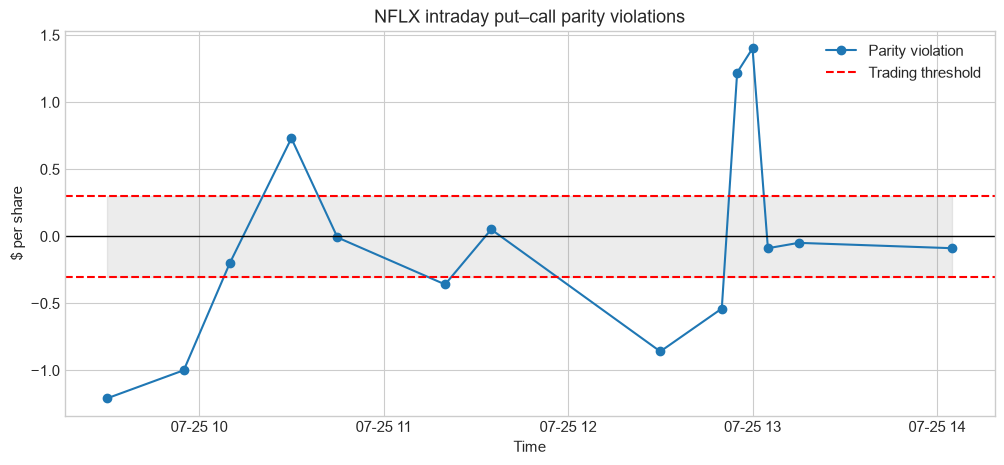

In [15]:
PCP_THRESHOLD = 0.30
PCP_CONTRACTS = 1_000
PCP_Q = PCP_CONTRACTS * CONTRACT_MULTIPLIER

pcp_df = pcp_prices.copy()
pcp_pvK = pcp_K / (1 + pcp_rate * pcp_days / 360)
pcp_df["C - P"] = pcp_df["call"] - pcp_df["put"]
pcp_df["S - PV(K)"] = pcp_df["underlying"] - pcp_pvK
pcp_df["violation"] = pcp_df["C - P"] - pcp_df["S - PV(K)"]

mean_abs_violation = pcp_df["violation"].abs().mean()
breach = pcp_df["violation"].abs() > PCP_THRESHOLD
n_conversion = (pcp_df["violation"] > PCP_THRESHOLD).sum()
n_reversal = (pcp_df["violation"] < -PCP_THRESHOLD).sum()

display(pcp_df.round(4))
print(f"PV(K): ${pcp_pvK:,.4f}")
print(f"Mean absolute violation: ${mean_abs_violation:,.4f}")
print(f"Violations beyond ±${PCP_THRESHOLD:.2f}: {breach.sum()} ")
print(f"Conversions: {n_conversion}; reversals: {n_reversal}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pcp_df.index, pcp_df["violation"], marker="o", label="Parity violation")
ax.axhline(0, color="black", lw=1)
ax.axhline(PCP_THRESHOLD, color="red", ls="--", label="Trading threshold")
ax.axhline(-PCP_THRESHOLD, color="red", ls="--")
ax.fill_between(pcp_df.index, -PCP_THRESHOLD, PCP_THRESHOLD, color="grey", alpha=0.15)
ax.set(title="NFLX intraday put–call parity violations", ylabel="$ per share", xlabel="Time")
ax.legend()
plt.show()

There are **8** violations beyond the $0.30 threshold: **3 conversions** and **5 reversals**. The mean absolute violation is approximately **$0.5573 per share**.

## 1.2 Total arbitrage P&L

,violation,trade type,transaction P&L,cumulative P&L
2025-07-25 09:30:00,-1.2087,Reversal,"$120,868.53","$120,868.53"
2025-07-25 09:55:00,-0.9987,Reversal,"$99,868.53","$220,737.06"
2025-07-25 10:10:00,-0.1987,No trade,$0.00,"$220,737.06"
2025-07-25 10:30:00,0.7313,Conversion,"$73,131.47","$293,868.53"
2025-07-25 10:45:00,-0.0087,No trade,$0.00,"$293,868.53"
2025-07-25 11:20:00,-0.3587,Reversal,"$35,868.53","$329,737.06"
2025-07-25 11:35:00,0.0513,No trade,$0.00,"$329,737.06"
2025-07-25 12:30:00,-0.8587,Reversal,"$85,868.53","$415,605.59"
2025-07-25 12:50:00,-0.5387,Reversal,"$53,868.53","$469,474.12"
2025-07-25 12:55:00,1.2213,Conversion,"$122,131.47","$591,605.59"


Total apparent intraday P&L: $731,737.06


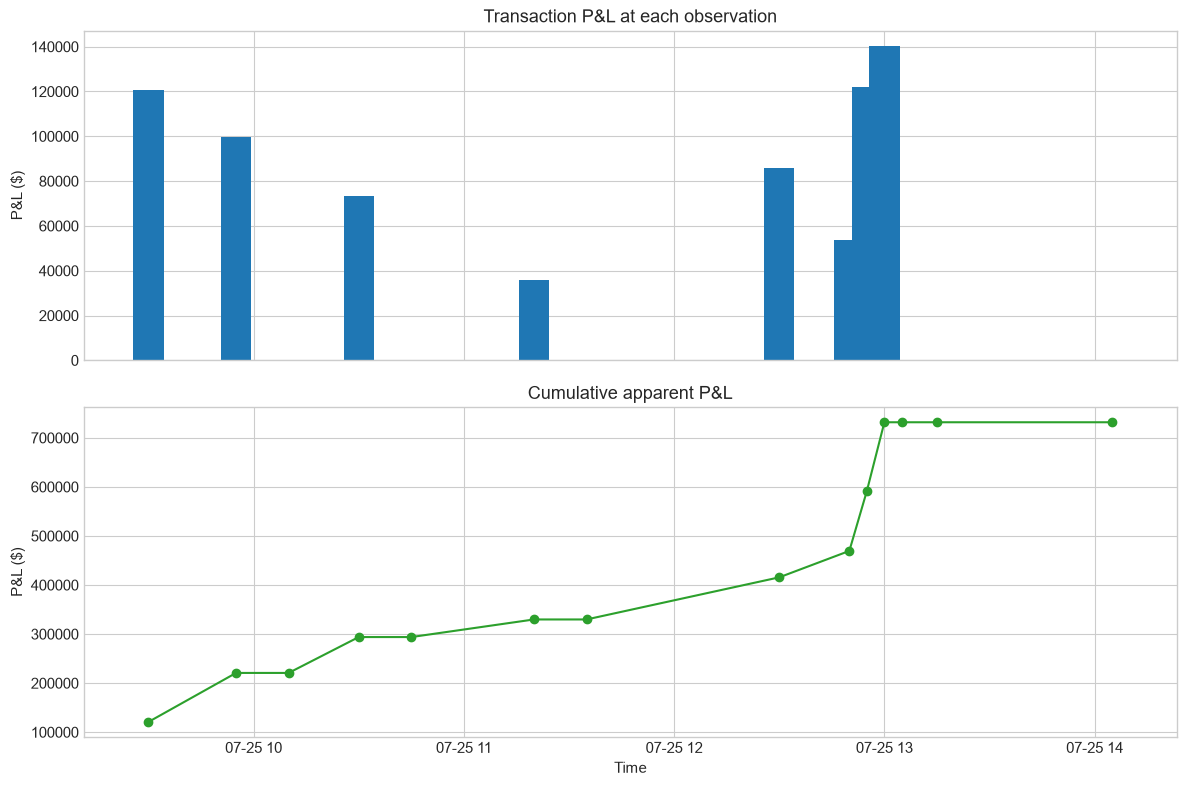

In [16]:
# direction = +1 for reversal and -1 for conversion.
pcp_df["direction"] = np.select(
    [pcp_df["violation"] < -PCP_THRESHOLD, pcp_df["violation"] > PCP_THRESHOLD],
    [1, -1], default=0
)
pcp_df["trade type"] = np.select(
    [pcp_df["direction"].eq(1), pcp_df["direction"].eq(-1)],
    ["Reversal", "Conversion"], default="No trade"
)
pcp_df["transaction P&L"] = pcp_df["violation"].abs() * PCP_Q * pcp_df["direction"].ne(0)
pcp_df["cumulative P&L"] = pcp_df["transaction P&L"].cumsum()

display(pcp_df[["violation", "trade type", "transaction P&L", "cumulative P&L"]]
        .style.format({"violation": "{:.4f}", "transaction P&L": "${:,.2f}", "cumulative P&L": "${:,.2f}"}))
print(f"Total apparent intraday P&L: ${pcp_df['transaction P&L'].sum():,.2f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].bar(pcp_df.index, pcp_df["transaction P&L"], width=0.006, color="tab:blue")
axes[0].set(title="Transaction P&L at each observation", ylabel="P&L ($)")
axes[1].plot(pcp_df.index, pcp_df["cumulative P&L"], marker="o", color="tab:green")
axes[1].set(title="Cumulative apparent P&L", ylabel="P&L ($)", xlabel="Time")
plt.tight_layout()
plt.show()

Trading every breach at 1,000 contracts produces a model-implied total P&L of **$731,737.06** before execution costs, liquidity constraints, and other frictions.

## 1.3 Cumulative positions

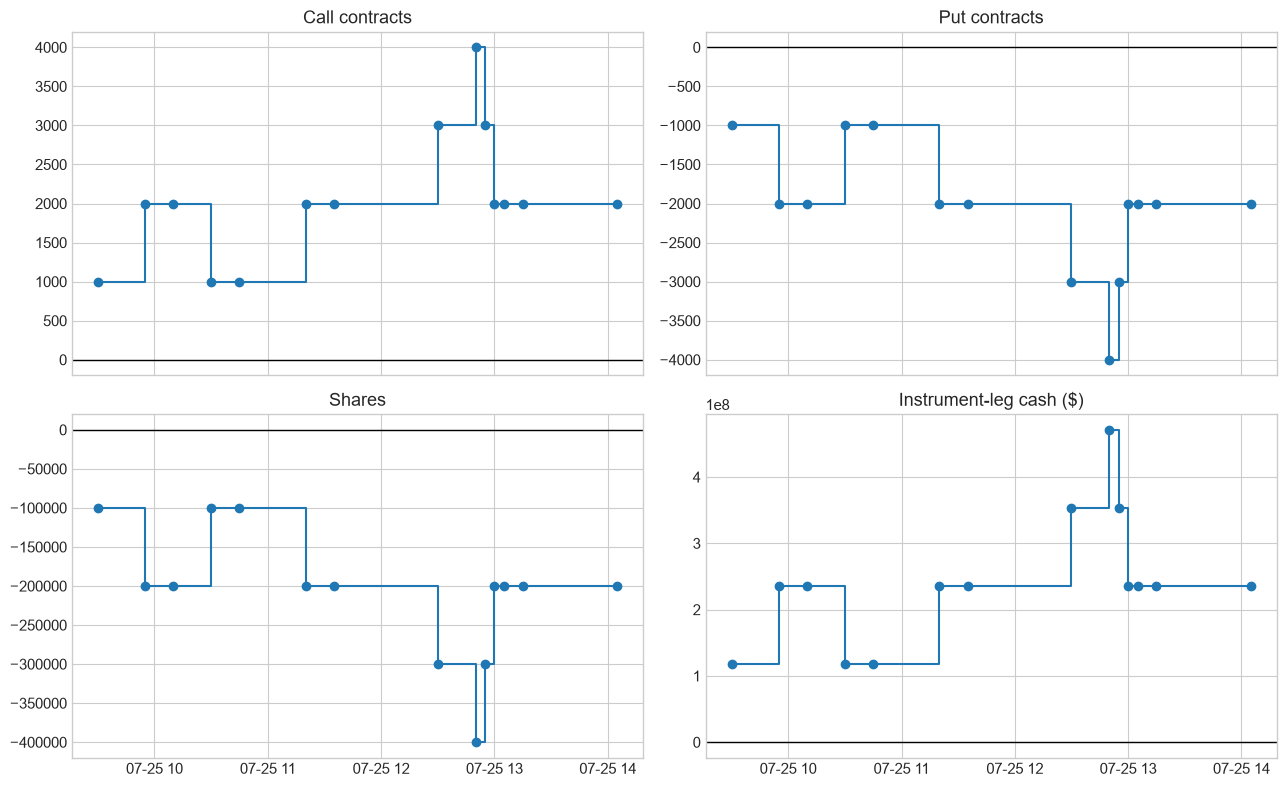

,Minimum,Maximum
Shares,"-400,000","-100,000"
Call contracts,"1,000","4,000"
Put contracts,"-4,000","-1,000"


In [17]:
d = pcp_df["direction"]

# Reversal (+1): long calls, short puts, short shares, lend PV(K).
# Conversion (-1): short calls, long puts, long shares, borrow PV(K).
pcp_df["call trade"] = d * PCP_CONTRACTS
pcp_df["put trade"] = -d * PCP_CONTRACTS
pcp_df["share trade"] = -d * PCP_Q
pcp_df["cash trade"] = -d * PCP_Q * (pcp_df["call"] - pcp_df["put"] - pcp_df["underlying"])
pcp_df["bond trade"] = -d * PCP_Q * pcp_pvK

for leg in ["call", "put", "share", "cash", "bond"]:
    pcp_df[f"cumulative {leg}"] = pcp_df[f"{leg} trade"].cumsum()

assert np.allclose(
    pcp_df["cumulative cash"] + pcp_df["cumulative bond"],
    pcp_df["cumulative P&L"],
)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
position_specs = [
    ("cumulative call", "Call contracts"),
    ("cumulative put", "Put contracts"),
    ("cumulative share", "Shares"),
    ("cumulative cash", "Instrument-leg cash ($)"),
]
for ax, (col, label) in zip(axes.flat, position_specs):
    ax.step(pcp_df.index, pcp_df[col], where="post", marker="o")
    ax.axhline(0, color="black", lw=1)
    ax.set_title(label)
plt.tight_layout()
plt.show()

position_summary = pd.DataFrame({
    "Minimum": [pcp_df["cumulative share"].min(), pcp_df["cumulative call"].min(), pcp_df["cumulative put"].min()],
    "Maximum": [pcp_df["cumulative share"].max(), pcp_df["cumulative call"].max(), pcp_df["cumulative put"].max()],
}, index=["Shares", "Call contracts", "Put contracts"])
display(position_summary.style.format("{:,.0f}"))

The strategy's cumulative positions range from −400,000 to −100,000 shares, 1,000 to 4,000 call contracts, and −4,000 to −1,000 put contracts. These positions arise because the exercise assumes every qualifying signal opens a new trade and does not close earlier positions intraday.

## 1.4 Why realized P&L would be lower

In [16]:
display(pcp_vol)
print("Observed five-minute option volume summary:")
display(pcp_vol.describe().round(2))
print(f"Assumed order size per option leg: {PCP_CONTRACTS:,} contracts")
print(f"Largest observed call volume: {pcp_vol['call_volume'].max():,.0f}")
print(f"Largest observed put volume: {pcp_vol['put_volume'].max():,.0f}")

,call_volume,put_volume
2025-07-25 09:30:00,1,1
2025-07-25 09:55:00,1,3
2025-07-25 10:10:00,23,3
2025-07-25 10:30:00,13,2
2025-07-25 10:45:00,22,3
2025-07-25 11:20:00,5,1
2025-07-25 11:35:00,18,2
2025-07-25 12:30:00,21,1
2025-07-25 12:50:00,2,1
2025-07-25 12:55:00,1,1


Observed five-minute option volume summary:


,call_volume,put_volume
count,14.0000,14.0000
mean,9.4300,2.0000
std,9.2300,1.4100
min,1.0000,1.0000
25%,2.0000,1.0000
50%,3.5000,1.5000
75%,18.7500,2.7500
max,23.0000,6.0000


Assumed order size per option leg: 1,000 contracts
Largest observed call volume: 23
Largest observed put volume: 6


The central problem is **liquidity**. The calculation assumes 1,000 contracts can be traded at each observed price, while observed five-minute call volume never exceeds 23 contracts and put volume never exceeds 6. A real order would exhaust displayed liquidity and move prices sharply. Bid–ask spreads, commissions, market impact, asynchronous quotes, partial fills, stock-borrow costs, financing differences, early assignment, and margin requirements would further reduce P&L. The $731,737 figure is therefore a frictionless upper bound, not a realistic realized profit forecast.

---

## Final numerical answers

- ATM mid-price signal: reversal; apparent profit about **$24,922**, but executable reversal P&L about **−$18,078**, so no quoted ATM arbitrage.
- ATM zero-profit financing rate for the exercise's conversion: about **3.4965%** ACT/360 (mid-price parity rate: **3.5308%**).
- Strike-270 mid-price conversion signal: apparent profit about **$1,218,593**; the raw put fields are stale/internally inconsistent and the executable conversion loses money.
- Package costs: **A $3,856**, **B $415**, **C $21,279**.
- Intraday: mean absolute violation **$0.5573**, **8** trades, apparent total P&L **$731,737.06**.